## A Simple Kinetic Solver

This solver can solve the kinetics of condensation and evaporation in and out of an aerosol. Can be improved by extending to xyz systems.

In [1]:
# Installing Packages

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

from numpy import random


In [2]:
# Creating Inputs

# Initial random generator seed
seed = 42
rng = random.default_rng(seed)

# Update to realistic k values later...
kf = 0.0001
kb = 0.1

# Calculation of equilibrium constant
K = kf/kb

time_step = 1 # second
total_time = 10000 # seconds for total run
ntime = int(total_time / time_step) # total number of calculations

# Initial paramaters
mol_L = 10000
mol_G = 0
time = 0

# Variables to be updated
L_remaining = mol_L
G_formed = mol_G

# Creating lists
L = []
G = []
times = []
sum_mol = []

In [3]:
# Loop over time

for t in range(ntime):
    time += time_step

    # append lists
    L.append(mol_L)
    G.append(mol_G)
    times.append(time)

    sum_of_mol = L_remaining + G_formed # Should remain constant thoughout experiment
    sum_mol.append(sum_of_mol)

    # Simple check, can be later removed
    print(f"time:{time}")
    print(f"L:{mol_L}")
    print(f"G:{mol_G}")

    # Solving reaction per one time step

    evaporation_sample = rng.random(L_remaining)
    L_evapped = evaporation_sample[evaporation_sample<=kf]
    
    condensation_sample = rng.random(G_formed)
    G_condensed = condensation_sample[condensation_sample<=kb]

    # Calculate loss/gain of L/G
    # Assume 1:1 ratio, every one gas molecule lost leads to one liquid moecule gained and vice versa
    L_lost = len(L_evapped)
    G_gain = L_lost

    G_lost = len(G_condensed)
    L_gain = G_lost

    # Calculate number of species remaining
    L_remaining = L_remaining + G_gain - L_lost
    G_formed = G_formed + G_gain - G_lost

print(f"There are {L_remaining} liquid molecules and {G_formed} gaseous molecules, with a total of {sum_of_mol} molecules in the system.")

time:1
L:10000
G:0
time:2
L:10000
G:0
time:3
L:10000
G:0
time:4
L:10000
G:0
time:5
L:10000
G:0
time:6
L:10000
G:0
time:7
L:10000
G:0
time:8
L:10000
G:0
time:9
L:10000
G:0
time:10
L:10000
G:0
time:11
L:10000
G:0
time:12
L:10000
G:0
time:13
L:10000
G:0
time:14
L:10000
G:0
time:15
L:10000
G:0
time:16
L:10000
G:0
time:17
L:10000
G:0
time:18
L:10000
G:0
time:19
L:10000
G:0
time:20
L:10000
G:0
time:21
L:10000
G:0
time:22
L:10000
G:0
time:23
L:10000
G:0
time:24
L:10000
G:0
time:25
L:10000
G:0
time:26
L:10000
G:0
time:27
L:10000
G:0
time:28
L:10000
G:0
time:29
L:10000
G:0
time:30
L:10000
G:0
time:31
L:10000
G:0
time:32
L:10000
G:0
time:33
L:10000
G:0
time:34
L:10000
G:0
time:35
L:10000
G:0
time:36
L:10000
G:0
time:37
L:10000
G:0
time:38
L:10000
G:0
time:39
L:10000
G:0
time:40
L:10000
G:0
time:41
L:10000
G:0
time:42
L:10000
G:0
time:43
L:10000
G:0
time:44
L:10000
G:0
time:45
L:10000
G:0
time:46
L:10000
G:0
time:47
L:10000
G:0
time:48
L:10000
G:0
time:49
L:10000
G:0
time:50
L:10000
G:0
time:51
L

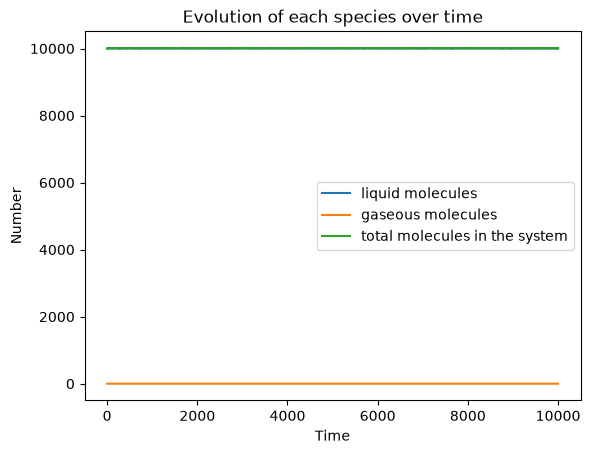

In [4]:
# Plotting evolution of species over time

plt.plot(times, L, label="liquid molecules")
plt.plot(times, G, label="gaseous molecules")
plt.plot(times, sum_mol, label="total molecules in the system") # expect a straight line

plt.title("Evolution of each species over time")
plt.xlabel("Time")
plt.ylabel("Number")
plt.legend()